# 20 — q-bin count vs f: accuracy & speed-up scan

How many daughter momentum bins does each fraction f actually need, and what does the
fluid approximation buy on top? Ground truth is the **exact hierarchy at q = 10001**;
every ladder rung (both arms) is judged against it on P(k) at z = 0.

**Run matrix** (defaults, matching `cluster_scripts/gen_nb20_cache.py`):
9 f-values × 6 eta-values = 54 corners; per corner one truth run + the 8-rung q-ladder
in both arms (exact and fluid) → 918 runs.

- **exact vs exact**: `ncdm_fluid_approximation = 3` at q ∈ ladder, vs truth. Isolates pure
  q-grid (phase-mixing) convergence — the q(f) schedule question.
- **fluid vs exact**: adiabatic-ceff2 fluid (`ncdm_ceff2_mode = 0`, `ncdm_ceff2_fs_amp = 0`,
  dynamical shear `switch_off_shear_acc = no`, abundance trigger 0.4) at the same rungs,
  vs the same truth. Shows whether the fluid switch buys speed at equal accuracy.

**This notebook is cache-only by default** (`ALLOW_COMPUTE = False`): it loads the pickles
produced on the cluster and reports what is missing instead of recomputing 918 runs on a
laptop. Generate with:

```
cd $HOME/Workplace/class_accDM/notebooks_test
python cluster_scripts/gen_nb20_cache.py --only truth --list     # 54 heavy jobs
qsub -t 0-53  -v 'GENERATOR=cluster_scripts/gen_nb20_cache.py,GEN_ARGS=--only truth'  cluster_scripts/submit_template.pbs
qsub -t 0-431 -v 'GENERATOR=cluster_scripts/gen_nb20_cache.py,GEN_ARGS=--only exact_' cluster_scripts/submit_template.pbs
qsub -t 0-431 -v 'GENERATOR=cluster_scripts/gen_nb20_cache.py,GEN_ARGS=--only fluid_' cluster_scripts/submit_template.pbs
```

then rsync `accDM_scans/nb20_cache/` back (see `cluster_scripts/README.md`). Partial
caches are fine — every plot below simply drops the missing points.

In [12]:
import os, time, pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.rcParams.update({
    'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5, 'figure.dpi': 200})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3', '#a65628', '#999999', '#e41a1c', '#dede00']

# --- base cosmology (same as nb15-nb19) ---
omega_b, omega_cdm0 = 0.022383, 0.12011
A_s, n_s, tau_reio, H0 = 2.1005829616811546e-9, 0.96605, 0.0543, 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
PREC = {'output': 'mPk', 'P_k_max_1/Mpc': 1.0, 'z_max_pk': 0.0,
        'evolver': 0, 'reionization_z_start_max': 80}
KAPPA, A_T, MASS = 12.1, 0.133, 1e16
A_REC = 1.0 / (1.0 + 1090.0)

# --- scan grids: KEEP IN SYNC with cluster_scripts/gen_nb20_cache.py defaults ---
F_GRID   = [1e-4, 1e-3, 1e-2, 0.03, 0.1, 0.2, 0.3, 0.5, 1.0]
ETA_GRID = [1e-8, 1e-6, 1e-4, 1e-2, 0.1, 1.0]
Q_LADDER = [201, 501, 751, 1001, 2001, 2501, 5001, 7501]
Q_TRUTH  = 10001
K_PK     = np.logspace(-3, 0.0, 40)

# --- accuracy windows, one per data-vector tier. The q-requirement is phase-
#     mixing resolution ~ k*tau(z), so each probe is scored on its own window:
#       core : Planck C_l + DESI distances + eBOSS full-shape (k <~ 0.3, z ~ 0)
#       lya  : Lyman-alpha, k ~ 1/Mpc at z ~ 3; tau(z=3) ~ 0.5 tau0 makes that
#              ~ k = 0.5 at z = 0 in phase terms (crude k*tau equivalence)
#       full : worst case, k to 1/Mpc at z = 0 (WL + one-loop territory)
K_WINDOWS = {'core': (0.05, 0.3), 'lya': (0.05, 0.5), 'full': (0.05, 1.0)}
K_DATA    = K_WINDOWS['full']   # headline window used by the single-window figures

# --- fluid configuration (encoded in the cache tag; keep in sync with the generator) ---
# trigger is the daughter/remaining-parent completeness gate (fires at ~t/(1+t)
# production complete, f-independent): t=10 = switch at ~91% converted.
TRIGGER, SHEAR = 10.0, 'no'     # matches the generated t10 cache; 'no' = dynamical shear
CEFF2_MODE, CEFF2_FS_AMP = 0, 0.0   # mode-0 fit with zero amplitude -> pure adiabatic ceff2
FLUID_PREFIX = 'fluid_m{}a{:g}_t{:g}_shear{}'.format(CEFF2_MODE, CEFF2_FS_AMP, TRIGGER, SHEAR)

CACHE_DIR = os.path.join('accDM_scans', 'nb20_cache'); os.makedirs(CACHE_DIR, exist_ok=True)
CACHE_TAG = 'v1'                # must match the generator's --cache-tag
ALLOW_COMPUTE = False           # True = compute missing entries locally (only for small subsets!)

color_of_f = {f_acc: qual_colors[i] for i, f_acc in enumerate(F_GRID)}
print('setup OK: {} corners, ladder {} + truth q={}, windows {}'.format(
    len(F_GRID)*len(ETA_GRID), Q_LADDER, Q_TRUTH, K_WINDOWS))

setup OK: 54 corners, ladder [201, 501, 751, 1001, 2001, 2501, 5001, 7501] + truth q=10001, windows {'core': (0.05, 0.3), 'lya': (0.05, 0.5), 'full': (0.05, 1.0)}


In [13]:
def accdm_params(f_acc, eta, q_size):
    """Exact-hierarchy accDM params (identical to nb18/nb19 and cluster common.py)."""
    ocdm = omega_cdm0 * (1 + f_acc*(1 - A_REC**KAPPA)/(1 + (A_REC/A_T)**KAPPA))**(-1)
    p = dict(base_params); p.update(PREC)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': KAPPA, 'a_t_acc': A_T,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, {}'.format(q_size), 'N_ur': 0.00441,
              'background_Nloga': 5001, 'gauge': 'synchronous',
              'get_perturbations_in_current_gauge': 'yes',
              'ncdm_fluid_trigger_tau_over_tau_k': 25,
              'ncdm_fluid_approximation': 3})           # 3 = none (exact hierarchy)
    return p

def fluid_params(f_acc, eta, q_size):
    """Adiabatic-ceff2 fluid: mode 0 with fs_amp = 0 makes ceff2 = ca2; dynamical shear."""
    p = accdm_params(f_acc, eta, q_size)
    p['ncdm_fluid_approximation'] = 2
    p['ncdm_fluid_trigger_rho_accDM_over_rho_dcdm'] = TRIGGER
    p['switch_off_shear_acc'] = SHEAR
    p['ncdm_ceff2_mode'] = CEFF2_MODE
    p['ncdm_ceff2_fs_amp'] = CEFF2_FS_AMP
    return p

def load_record(tag, params_thunk=None):
    """Cache-first loader. Returns dict(pk, sigma8, seconds) or None if missing
    and ALLOW_COMPUTE is off. Quiet on cache hits (918 files)."""
    cache_file = os.path.join(CACHE_DIR, '{}_{}.pkl'.format(CACHE_TAG, tag))
    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as fh:
            return pickle.load(fh)
    if not ALLOW_COMPUTE or params_thunk is None:
        return None
    from classy import Class
    print('[run  ] {} ...'.format(tag), flush=True)
    t_start = time.time()
    cosmo = Class(); cosmo.set(params_thunk()); cosmo.compute()
    pk_values = np.array([cosmo.pk(k_value, 0.0) for k_value in K_PK])
    rec = {'pk': pk_values, 'sigma8': cosmo.sigma8(), 'seconds': time.time() - t_start}
    cosmo.struct_cleanup(); cosmo.empty()
    with open(cache_file, 'wb') as fh:
        pickle.dump(rec, fh)
    print('[done ] {} {:.0f} s'.format(tag, rec['seconds']))
    return rec

def truth_tag(f_acc, eta):
    return 'truth_f{:g}_eta{:g}_q{}'.format(f_acc, eta, Q_TRUTH)

def exact_tag(f_acc, eta, q_size):
    return 'exact_f{:g}_eta{:g}_q{}'.format(f_acc, eta, q_size)

def fluid_tag(f_acc, eta, q_size):
    return '{}_f{:g}_eta{:g}_q{}'.format(FLUID_PREFIX, f_acc, eta, q_size)

In [14]:
# --- load everything the cache has; report coverage instead of recomputing ---
records, missing = {}, []
corners = [(f_acc, eta) for f_acc in F_GRID for eta in ETA_GRID]
for f_acc, eta in tqdm(corners, desc='loading corners'):
    jobs = [(('truth', f_acc, eta, Q_TRUTH), truth_tag(f_acc, eta),
             lambda f=f_acc, e=eta: accdm_params(f, e, Q_TRUTH))]
    for q_size in Q_LADDER:
        jobs.append((('exact', f_acc, eta, q_size), exact_tag(f_acc, eta, q_size),
                     lambda f=f_acc, e=eta, q=q_size: accdm_params(f, e, q)))
        jobs.append((('fluid', f_acc, eta, q_size), fluid_tag(f_acc, eta, q_size),
                     lambda f=f_acc, e=eta, q=q_size: fluid_params(f, e, q)))
    for key, tag, thunk in jobs:
        rec = load_record(tag, thunk)
        if rec is None:
            missing.append(tag)
        else:
            records[key] = rec

expected = len(corners) * (1 + 2*len(Q_LADDER))
print('loaded {} / {} records'.format(len(records), expected))
for kind in ('truth', 'exact', 'fluid'):
    have = sum(1 for key in records if key[0] == kind)
    total = len(corners) * (1 if kind == 'truth' else len(Q_LADDER))
    print('  {:6s} {:4d} / {}'.format(kind, have, total))
if missing:
    print('missing (first 15):'); [print('   ', tag) for tag in missing[:15]]

loading corners: 100%|██████████| 54/54 [00:20<00:00,  2.69it/s]

loaded 916 / 918 records
  truth    52 / 54
  exact   432 / 432
  fluid   432 / 432
missing (first 15):
    truth_f0.3_eta1e-08_q10001
    truth_f0.3_eta1e-06_q10001


## Metrics

Per run, against the same-corner truth:

- `err_grid` — max |P/P_truth − 1| over the whole k grid (10⁻³–1 /Mpc);
- `err_core` / `err_lya` / `err_full` — the same max restricted to each `K_WINDOWS`
  tier (core = Planck+DESI+eBOSS, k ≤ 0.3; lya = Lyman-α phase-equivalent, k ≤ 0.5;
  full = k ≤ 1 worst case). `err_win` is kept as an alias of `err_full` — the
  headline number the single-window figures use;
- `dsig8`    — |σ₈/σ₈_truth − 1|;
- `speedup`  — seconds_truth / seconds (cluster wall times, same ppn for every job;
  NB the ten straggler truths (f = 0.2/0.3, array block 31–40) ran on a slow node,
  so their speed-up rows are ~10× inflated — timing artifact, accuracy unaffected).

Rungs whose corner lacks a truth run are dropped.

In [15]:
window_masks = {name: (K_PK >= lo) & (K_PK <= hi) for name, (lo, hi) in K_WINDOWS.items()}
metrics = {}
for key, rec in records.items():
    kind, f_acc, eta, q_size = key
    if kind == 'truth':
        continue
    truth = records.get(('truth', f_acc, eta, Q_TRUTH))
    if truth is None:
        continue
    rel_err = rec['pk'] / truth['pk'] - 1.0
    entry = {
        'err_grid': float(np.max(np.abs(rel_err))),
        'dsig8': abs(rec['sigma8'] / truth['sigma8'] - 1.0),
        'seconds': rec['seconds'],
        'speedup': truth['seconds'] / rec['seconds'],
    }
    for name, mask in window_masks.items():
        entry['err_' + name] = float(np.max(np.abs(rel_err[mask])))
    entry['err_win'] = entry['err_full']    # headline alias for the single-window figures
    metrics[key] = entry

def metric(kind, f_acc, eta, q_size, name):
    entry = metrics.get((kind, f_acc, eta, q_size))
    return np.nan if entry is None else entry[name]

def ladder_curve(kind, f_acc, eta, name):
    """(q_values, metric_values) restricted to rungs that exist."""
    qs = [q for q in Q_LADDER if (kind, f_acc, eta, q) in metrics]
    return np.array(qs), np.array([metrics[(kind, f_acc, eta, q)][name] for q in qs])

print('metrics for {} runs, windows: {}'.format(len(metrics), list(K_WINDOWS)))

metrics for 832 runs, windows: ['core', 'lya', 'full']


In [16]:
### Print times for q_bins=1000

for kind in ('exact', 'fluid'):
    print('\n{} timings (seconds) for q_bins=1000'.format(kind))
    print('f_acc\teta\ttime')
    for f_acc in F_GRID:
        for eta in ETA_GRID:
            t = metric(kind, f_acc, eta, 1001, 'seconds')
            print('{:g}\t{:g}\t{:.2f}'.format(f_acc, eta, t))


exact timings (seconds) for q_bins=1000
f_acc	eta	time
0.0001	1e-08	92.21
0.0001	1e-06	93.05
0.0001	0.0001	89.70
0.0001	0.01	88.33
0.0001	0.1	91.59
0.0001	1	87.56
0.001	1e-08	99.56
0.001	1e-06	100.68
0.001	0.0001	98.03
0.001	0.01	91.66
0.001	0.1	91.66
0.001	1	90.63
0.01	1e-08	98.25
0.01	1e-06	96.48
0.01	0.0001	98.37
0.01	0.01	94.22
0.01	0.1	93.08
0.01	1	91.57
0.03	1e-08	96.40
0.03	1e-06	94.40
0.03	0.0001	98.79
0.03	0.01	92.00
0.03	0.1	91.26
0.03	1	95.93
0.1	1e-08	97.49
0.1	1e-06	95.86
0.1	0.0001	93.73
0.1	0.01	101.96
0.1	0.1	90.28
0.1	1	89.64
0.2	1e-08	110.01
0.2	1e-06	106.17
0.2	0.0001	94.21
0.2	0.01	92.01
0.2	0.1	91.73
0.2	1	100.97
0.3	1e-08	nan
0.3	1e-06	nan
0.3	0.0001	105.09
0.3	0.01	104.23
0.3	0.1	104.14
0.3	1	90.73
0.5	1e-08	97.26
0.5	1e-06	100.04
0.5	0.0001	101.37
0.5	0.01	95.55
0.5	0.1	97.95
0.5	1	92.36
1	1e-08	98.11
1	1e-06	89.90
1	0.0001	88.08
1	0.01	84.01
1	0.1	85.15
1	1	83.32

fluid timings (seconds) for q_bins=1000
f_acc	eta	time
0.0001	1e-08	63.51
0.0001	1e-06	66.40
0.00

## 1. q-grid convergence: accuracy vs q per f (panel per eta)

Exact arm = pure momentum-resolution error (free-streaming phase-mixing).
Fluid arm = q-grid error before switch-on **plus** the closure error, which does not
vanish as q → truth: a plateau at high q is the fluid's intrinsic accuracy floor.

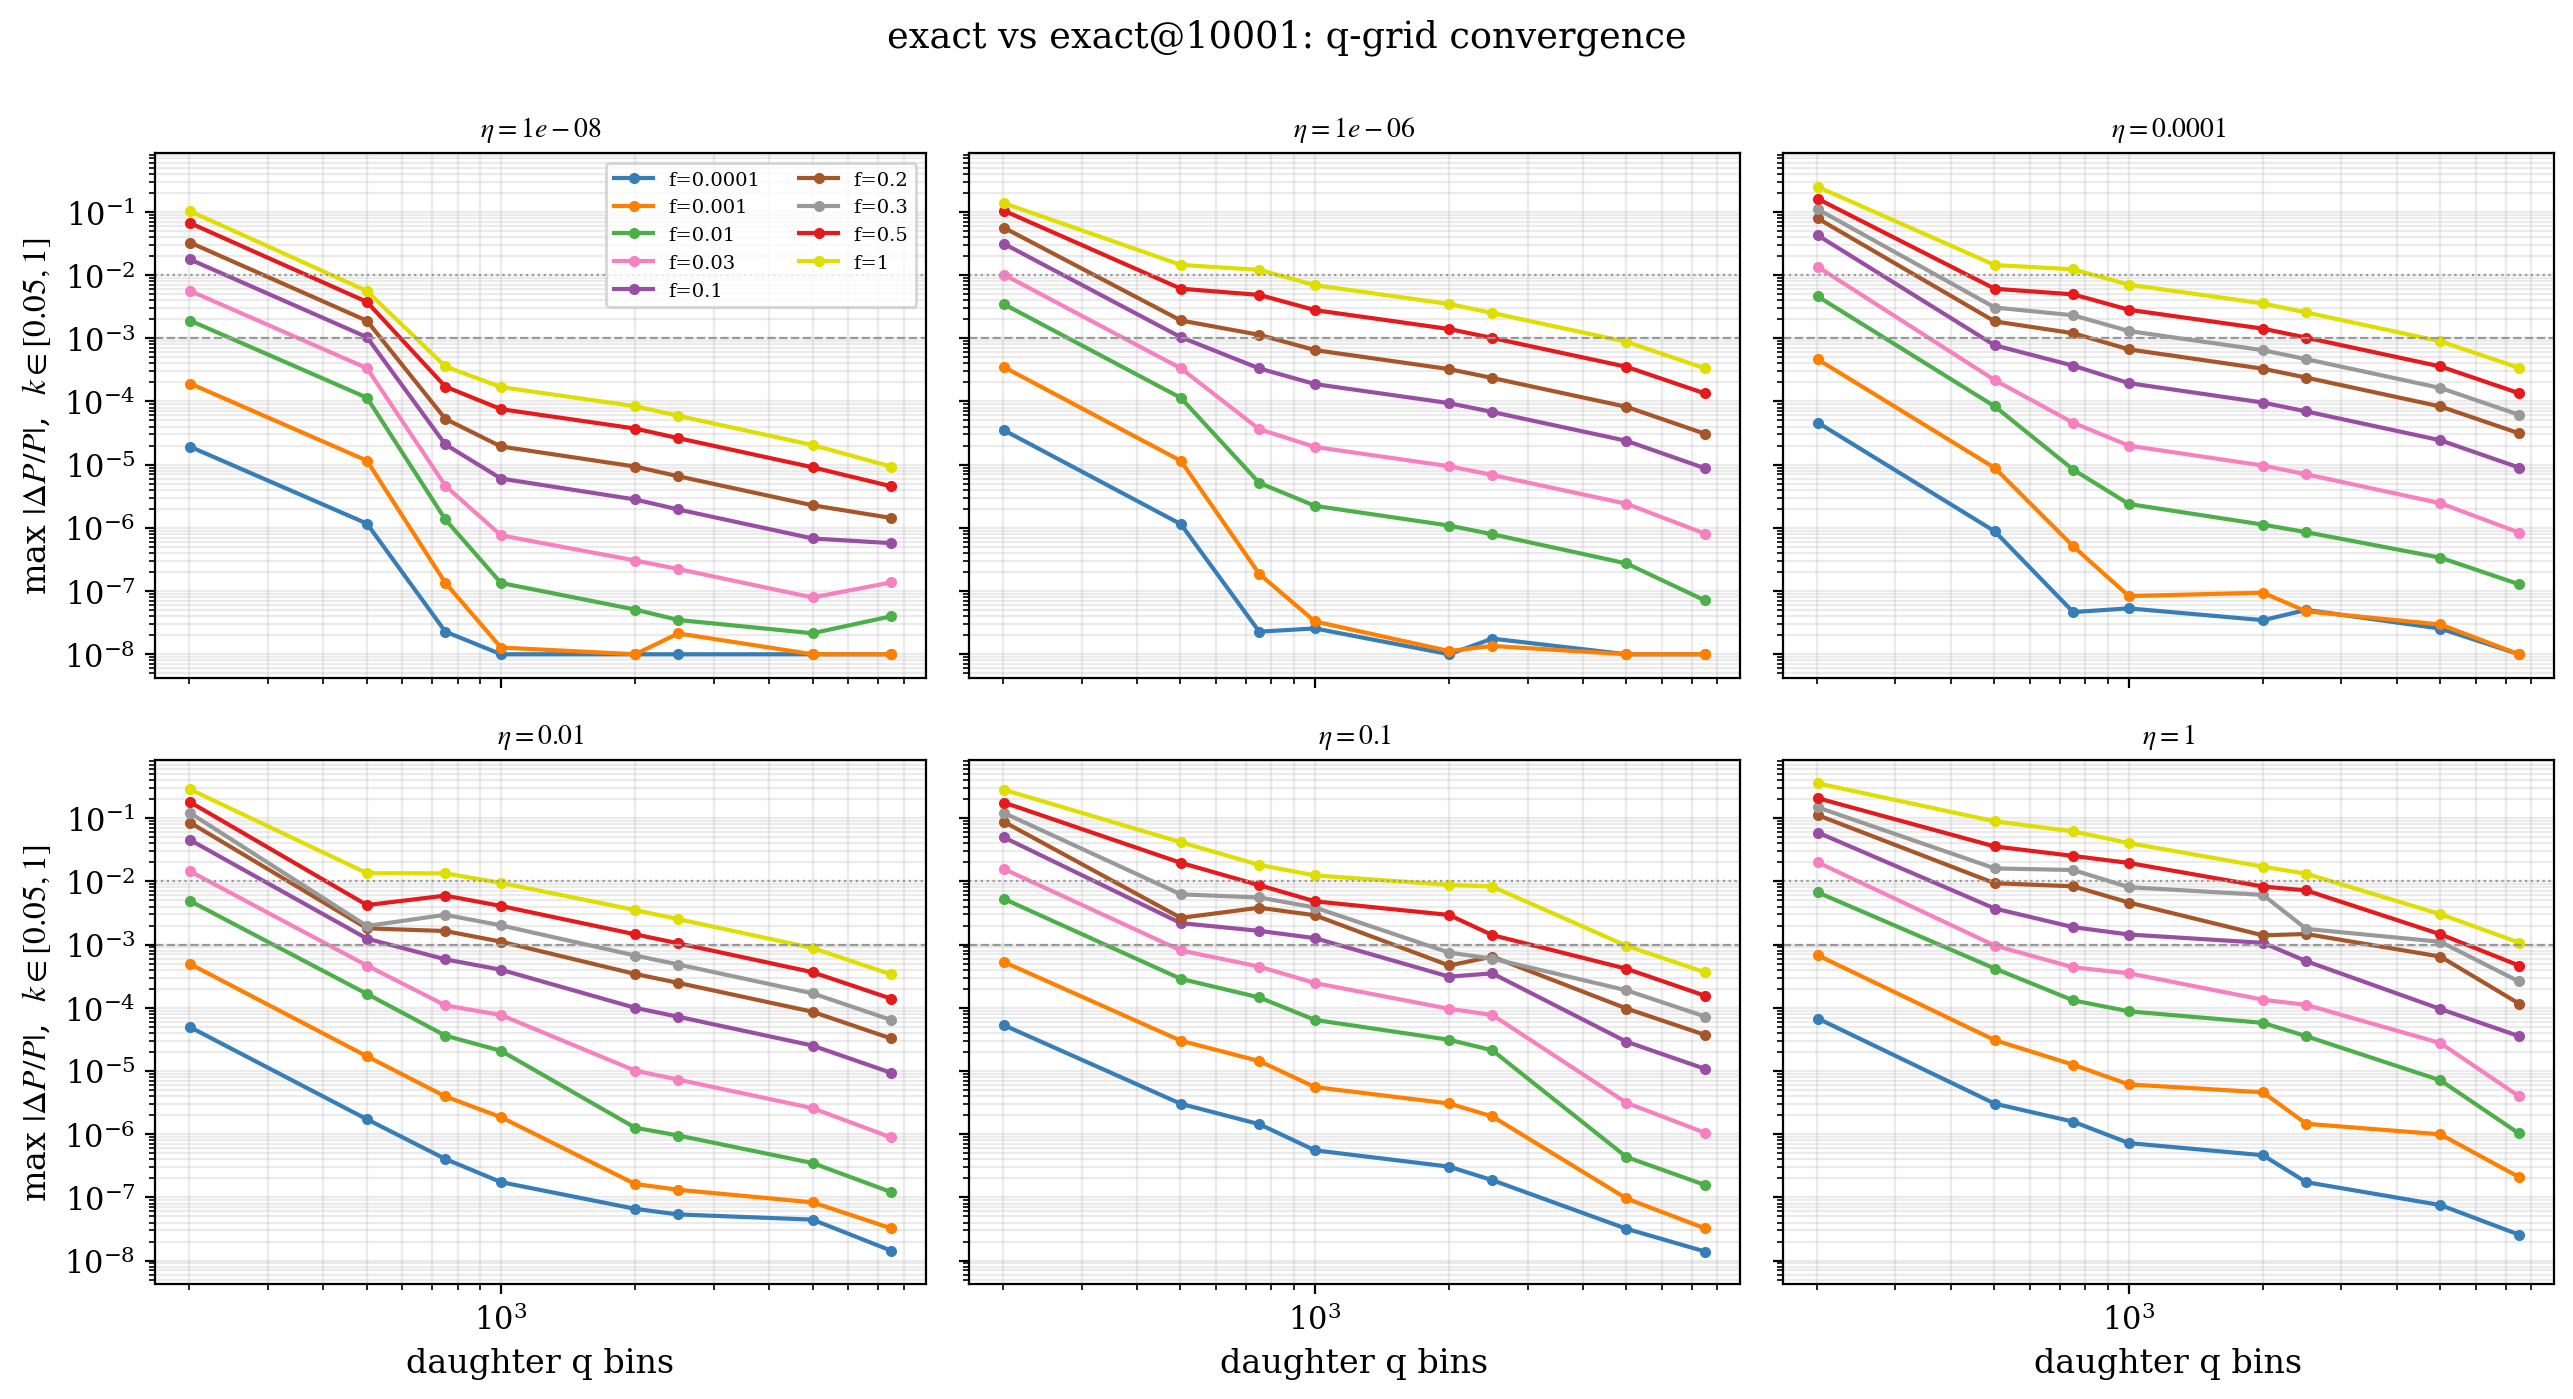

In [17]:
from matplotlib.lines import Line2D

def f_legend_handles():
    """Legend built from the full f grid, not from whichever lines panel 1 happens
    to have data for (a corner with a missing truth would silently drop its entry)."""
    return [Line2D([0], [0], color=color_of_f[f_acc], marker='o', ms=3,
                   label='f={:g}'.format(f_acc)) for f_acc in F_GRID]

def accuracy_panels(kind, title, err_key='err_win'):
    fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
    for ax, eta in zip(axes.flat, ETA_GRID):
        for f_acc in F_GRID:
            q_values, err_values = ladder_curve(kind, f_acc, eta, err_key)
            if len(q_values):
                ax.loglog(q_values, np.maximum(err_values, 1e-8), 'o-', ms=3,
                          color=color_of_f[f_acc])
        for target, style in ((1e-2, ':'), (1e-3, '--')):
            ax.axhline(target, color='0.6', lw=0.8, ls=style)
        ax.set_title(r'$\eta = {:g}$'.format(eta), fontsize=10)
        ax.grid(alpha=0.25, which='both')
    for ax in axes[-1]:
        ax.set_xlabel('daughter q bins')
    for ax in axes[:, 0]:
        ax.set_ylabel(r'max $|\Delta P/P|$,  $k \in [{:g}, {:g}]$'.format(*K_WINDOWS[err_key[4:]])
                      if err_key[4:] in K_WINDOWS else err_key)
    axes[0, 0].legend(handles=f_legend_handles(), ncol=2, fontsize=7)
    fig.suptitle(title, y=0.995)
    fig.tight_layout()
    return fig

accuracy_panels('exact', 'exact vs exact@{}: q-grid convergence'.format(Q_TRUTH), 'err_full');

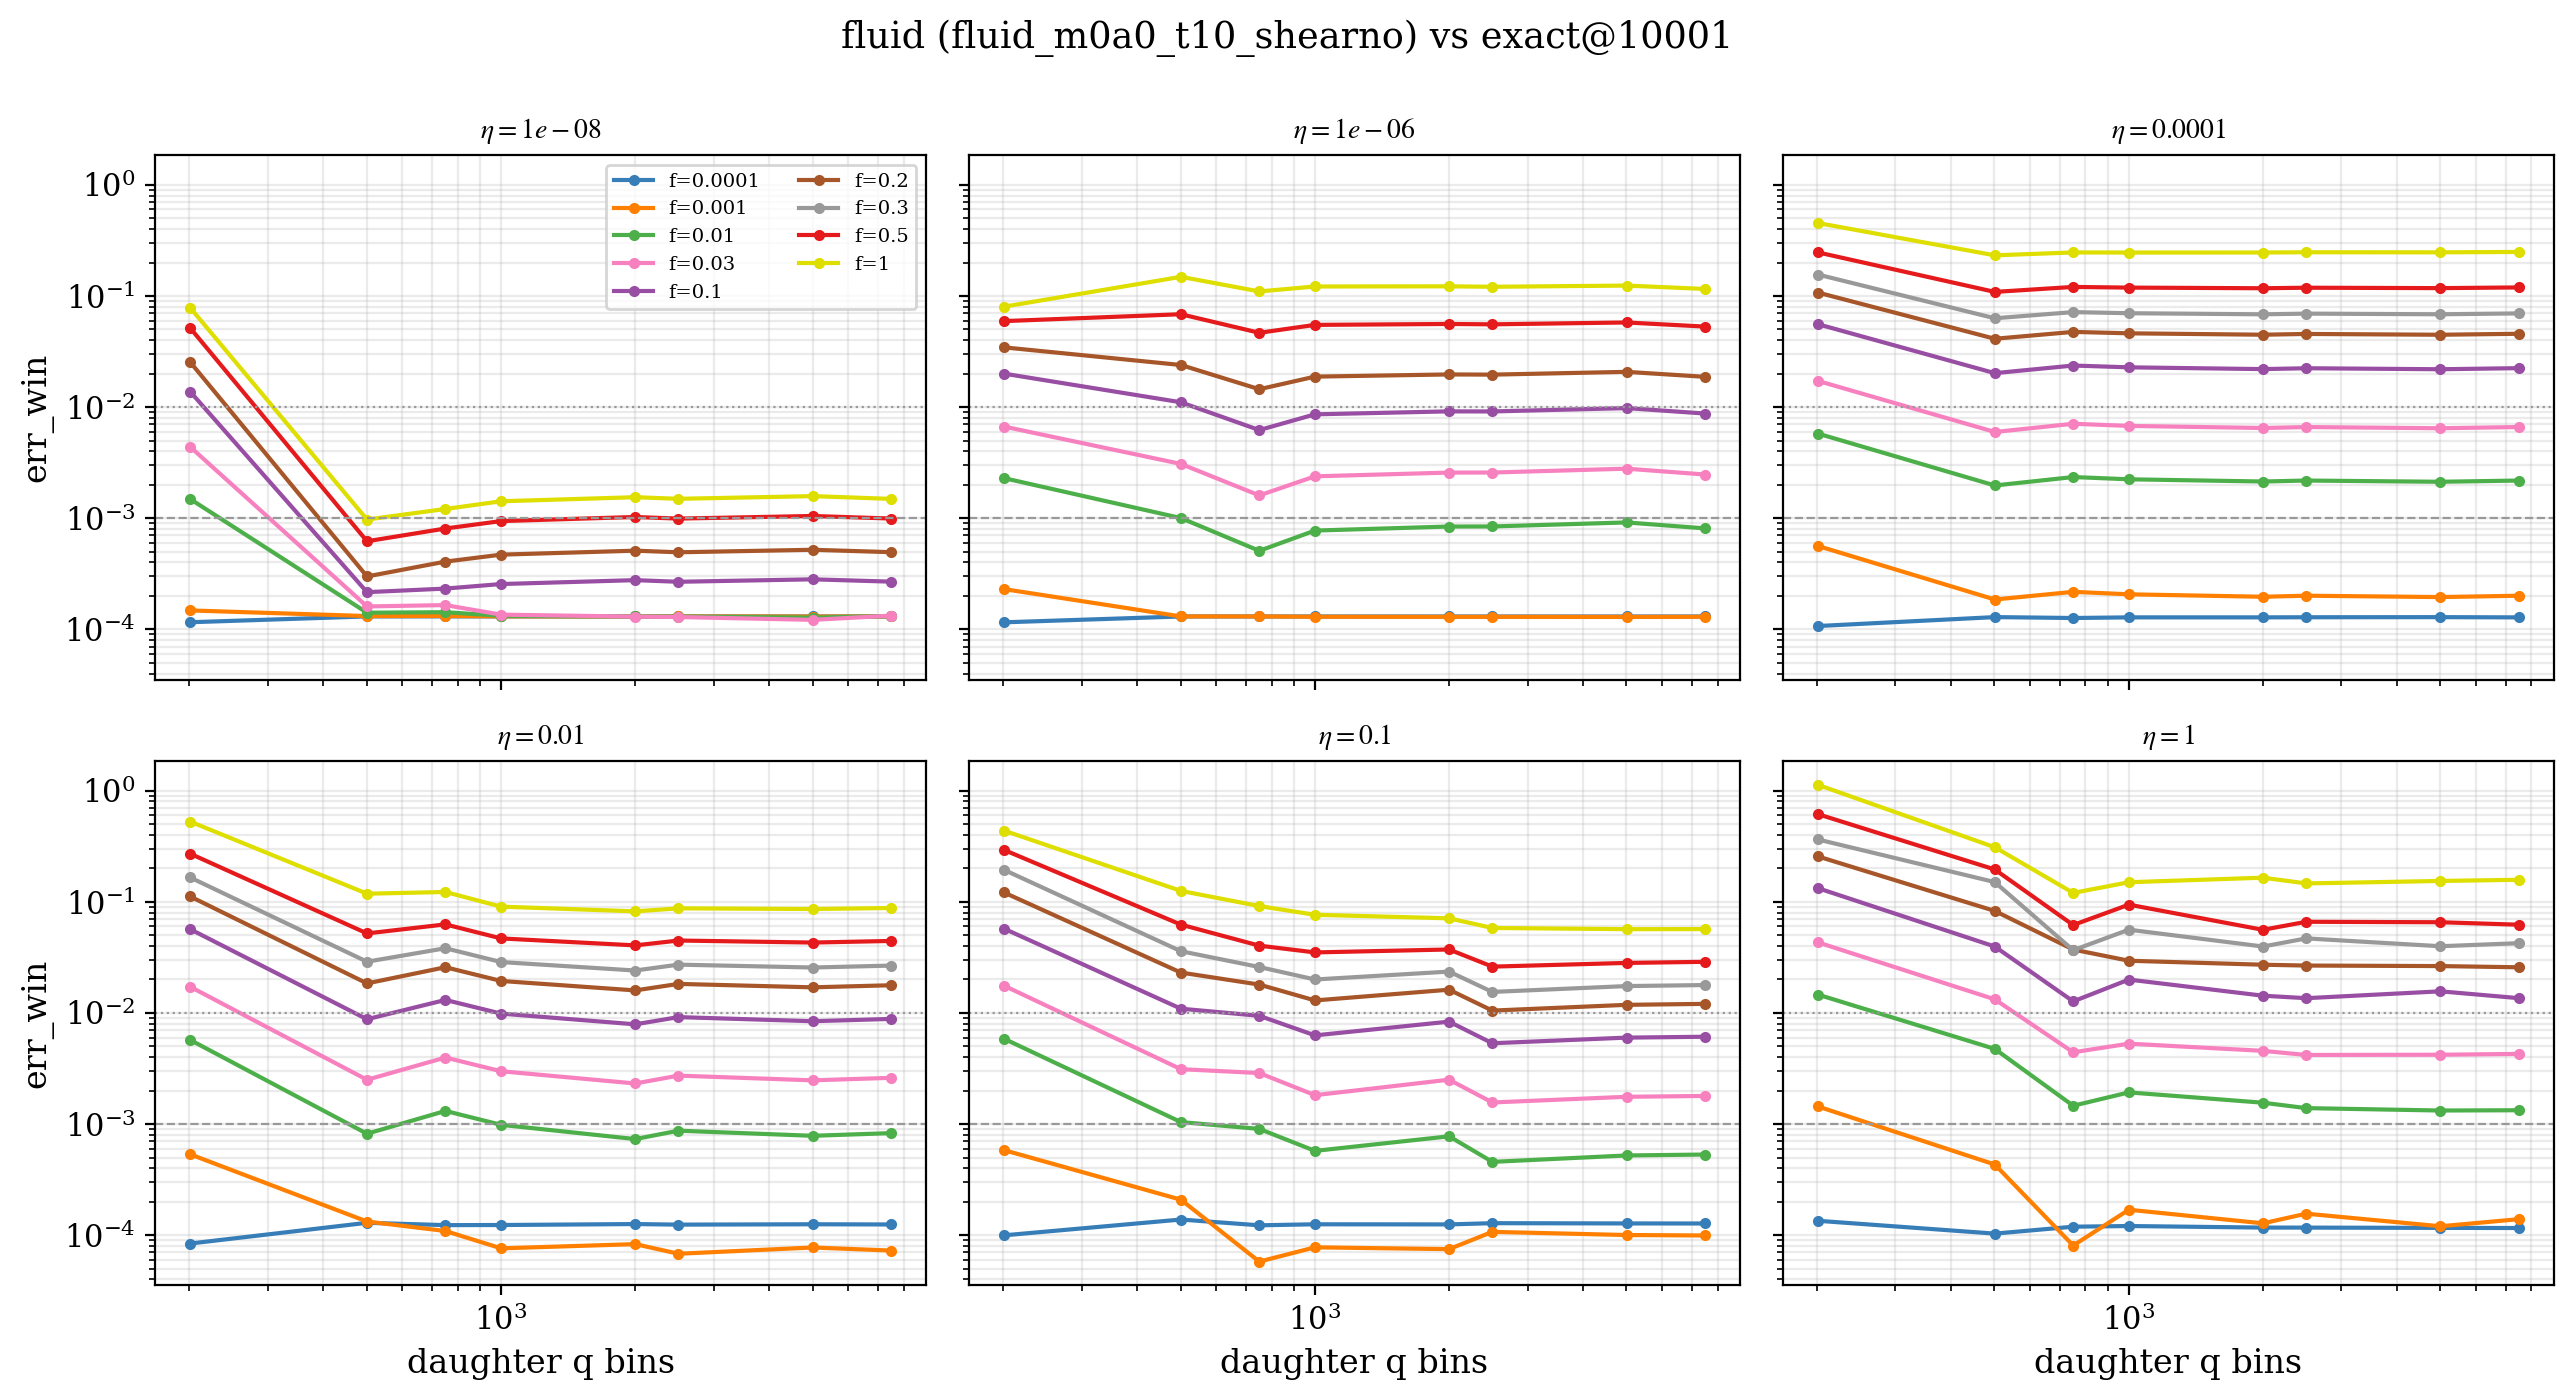

In [18]:
accuracy_panels('fluid', 'fluid ({}) vs exact@{}'.format(FLUID_PREFIX, Q_TRUTH));

## 2. Speed-up vs q (relative to the truth run of the same corner)

Solid = exact arm, dashed = fluid arm. The gap between the two line families at fixed q
is what the fluid switch itself buys; the slope is what the q-grid buys.

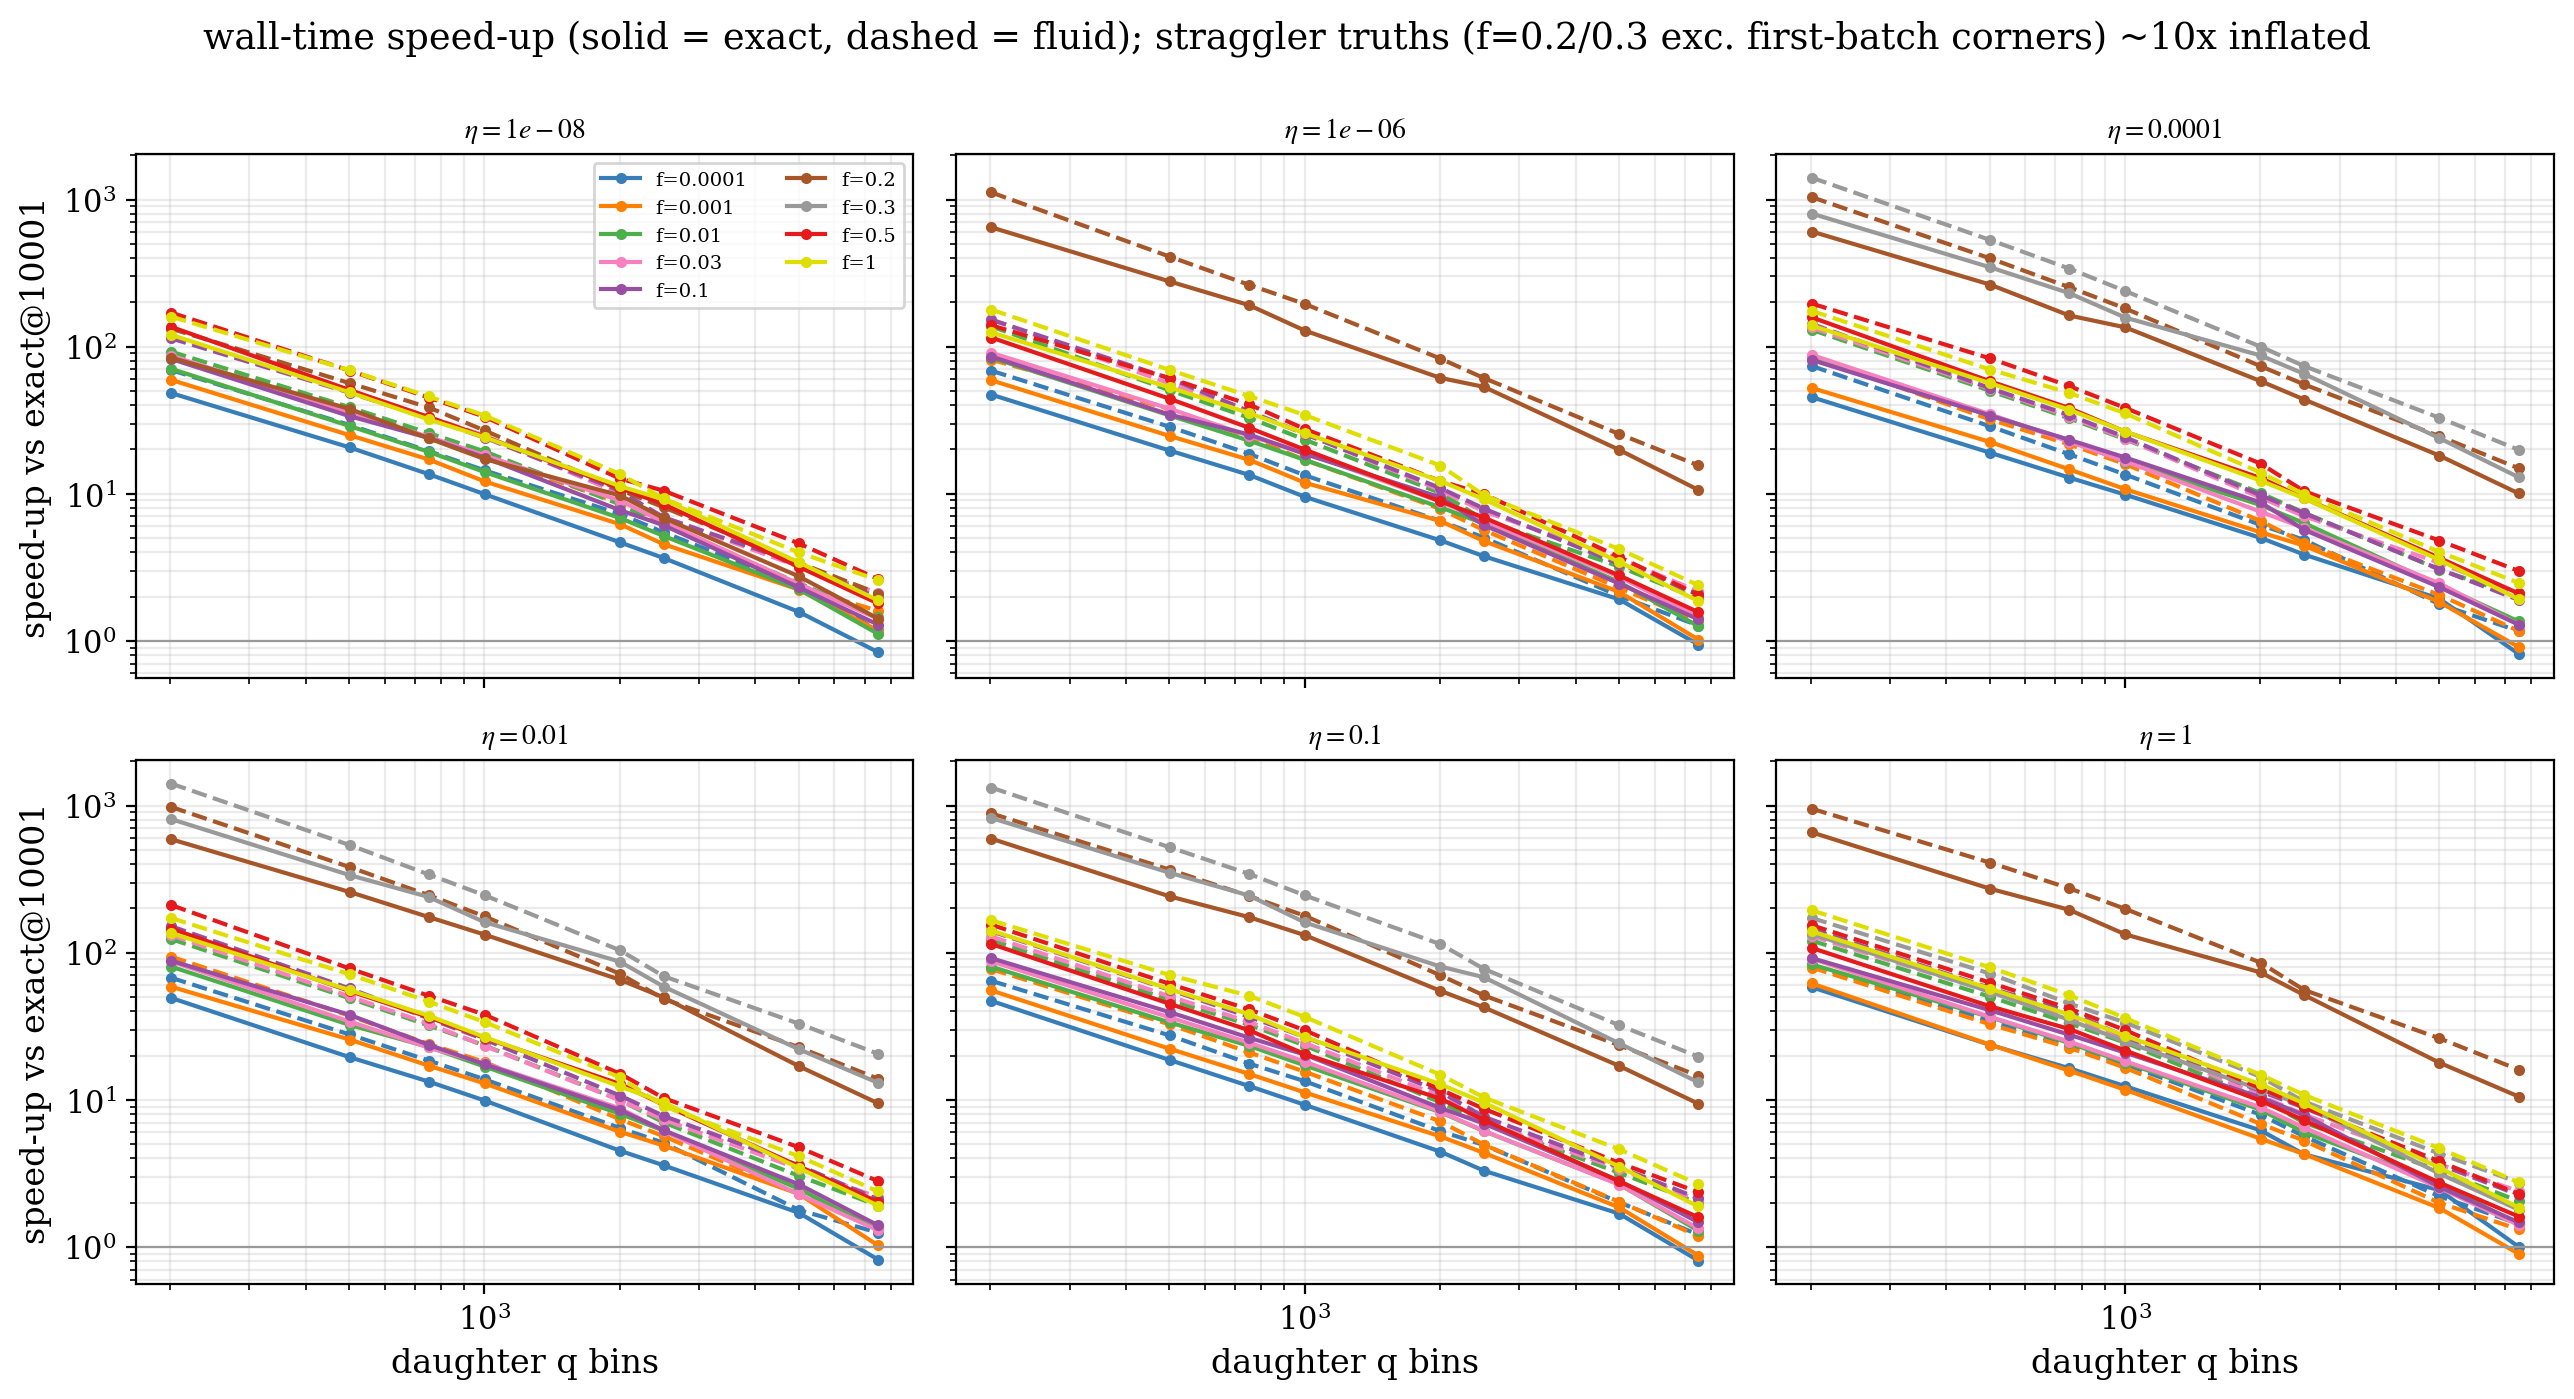

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ax, eta in zip(axes.flat, ETA_GRID):
    for f_acc in F_GRID:
        for kind, linestyle in (('exact', '-'), ('fluid', '--')):
            q_values, speedups = ladder_curve(kind, f_acc, eta, 'speedup')
            if len(q_values):
                ax.loglog(q_values, speedups, linestyle, marker='o', ms=3,
                          color=color_of_f[f_acc])
    ax.axhline(1.0, color='0.6', lw=0.8)
    ax.set_title(r'$\eta = {:g}$'.format(eta), fontsize=10)
    ax.grid(alpha=0.25, which='both')
for ax in axes[-1]:
    ax.set_xlabel('daughter q bins')
for ax in axes[:, 0]:
    ax.set_ylabel('speed-up vs exact@{}'.format(Q_TRUTH))
axes[0, 0].legend(handles=f_legend_handles(), ncol=2, fontsize=7)
fig.suptitle('wall-time speed-up (solid = exact, dashed = fluid); '
             'straggler truths (f=0.2/0.3 exc. first-batch corners) ~10x inflated', y=0.995)
fig.tight_layout()

## 3. The q(f) schedule per data-vector tier

For each corner and arm, the smallest ladder rung with the window error ≤ target,
**scored separately on each `K_WINDOWS` tier** — read the sanctioned q for a given
likelihood off its own panel set instead of inheriting the k = 1, z = 0 worst case:

- **core** (k ≤ 0.3): Planck + DESI distances + eBOSS full-shape — the baseline chains;
- **lya** (k ≤ 0.5): phase-equivalent of Lyman-α's k ~ 1/Mpc at z ~ 3 (k·τ scaling);
- **full** (k ≤ 1): weak lensing + one-loop territory at z = 0.

Missing marker = no rung on the ladder meets the target (for the fluid arm that
usually means the closure floor, not the q-grid, is the binding constraint).
Everything is scored at z = 0, where τ (and hence the phase-mixing demand) is
largest — so all three schedules are conservative for high-z observables.

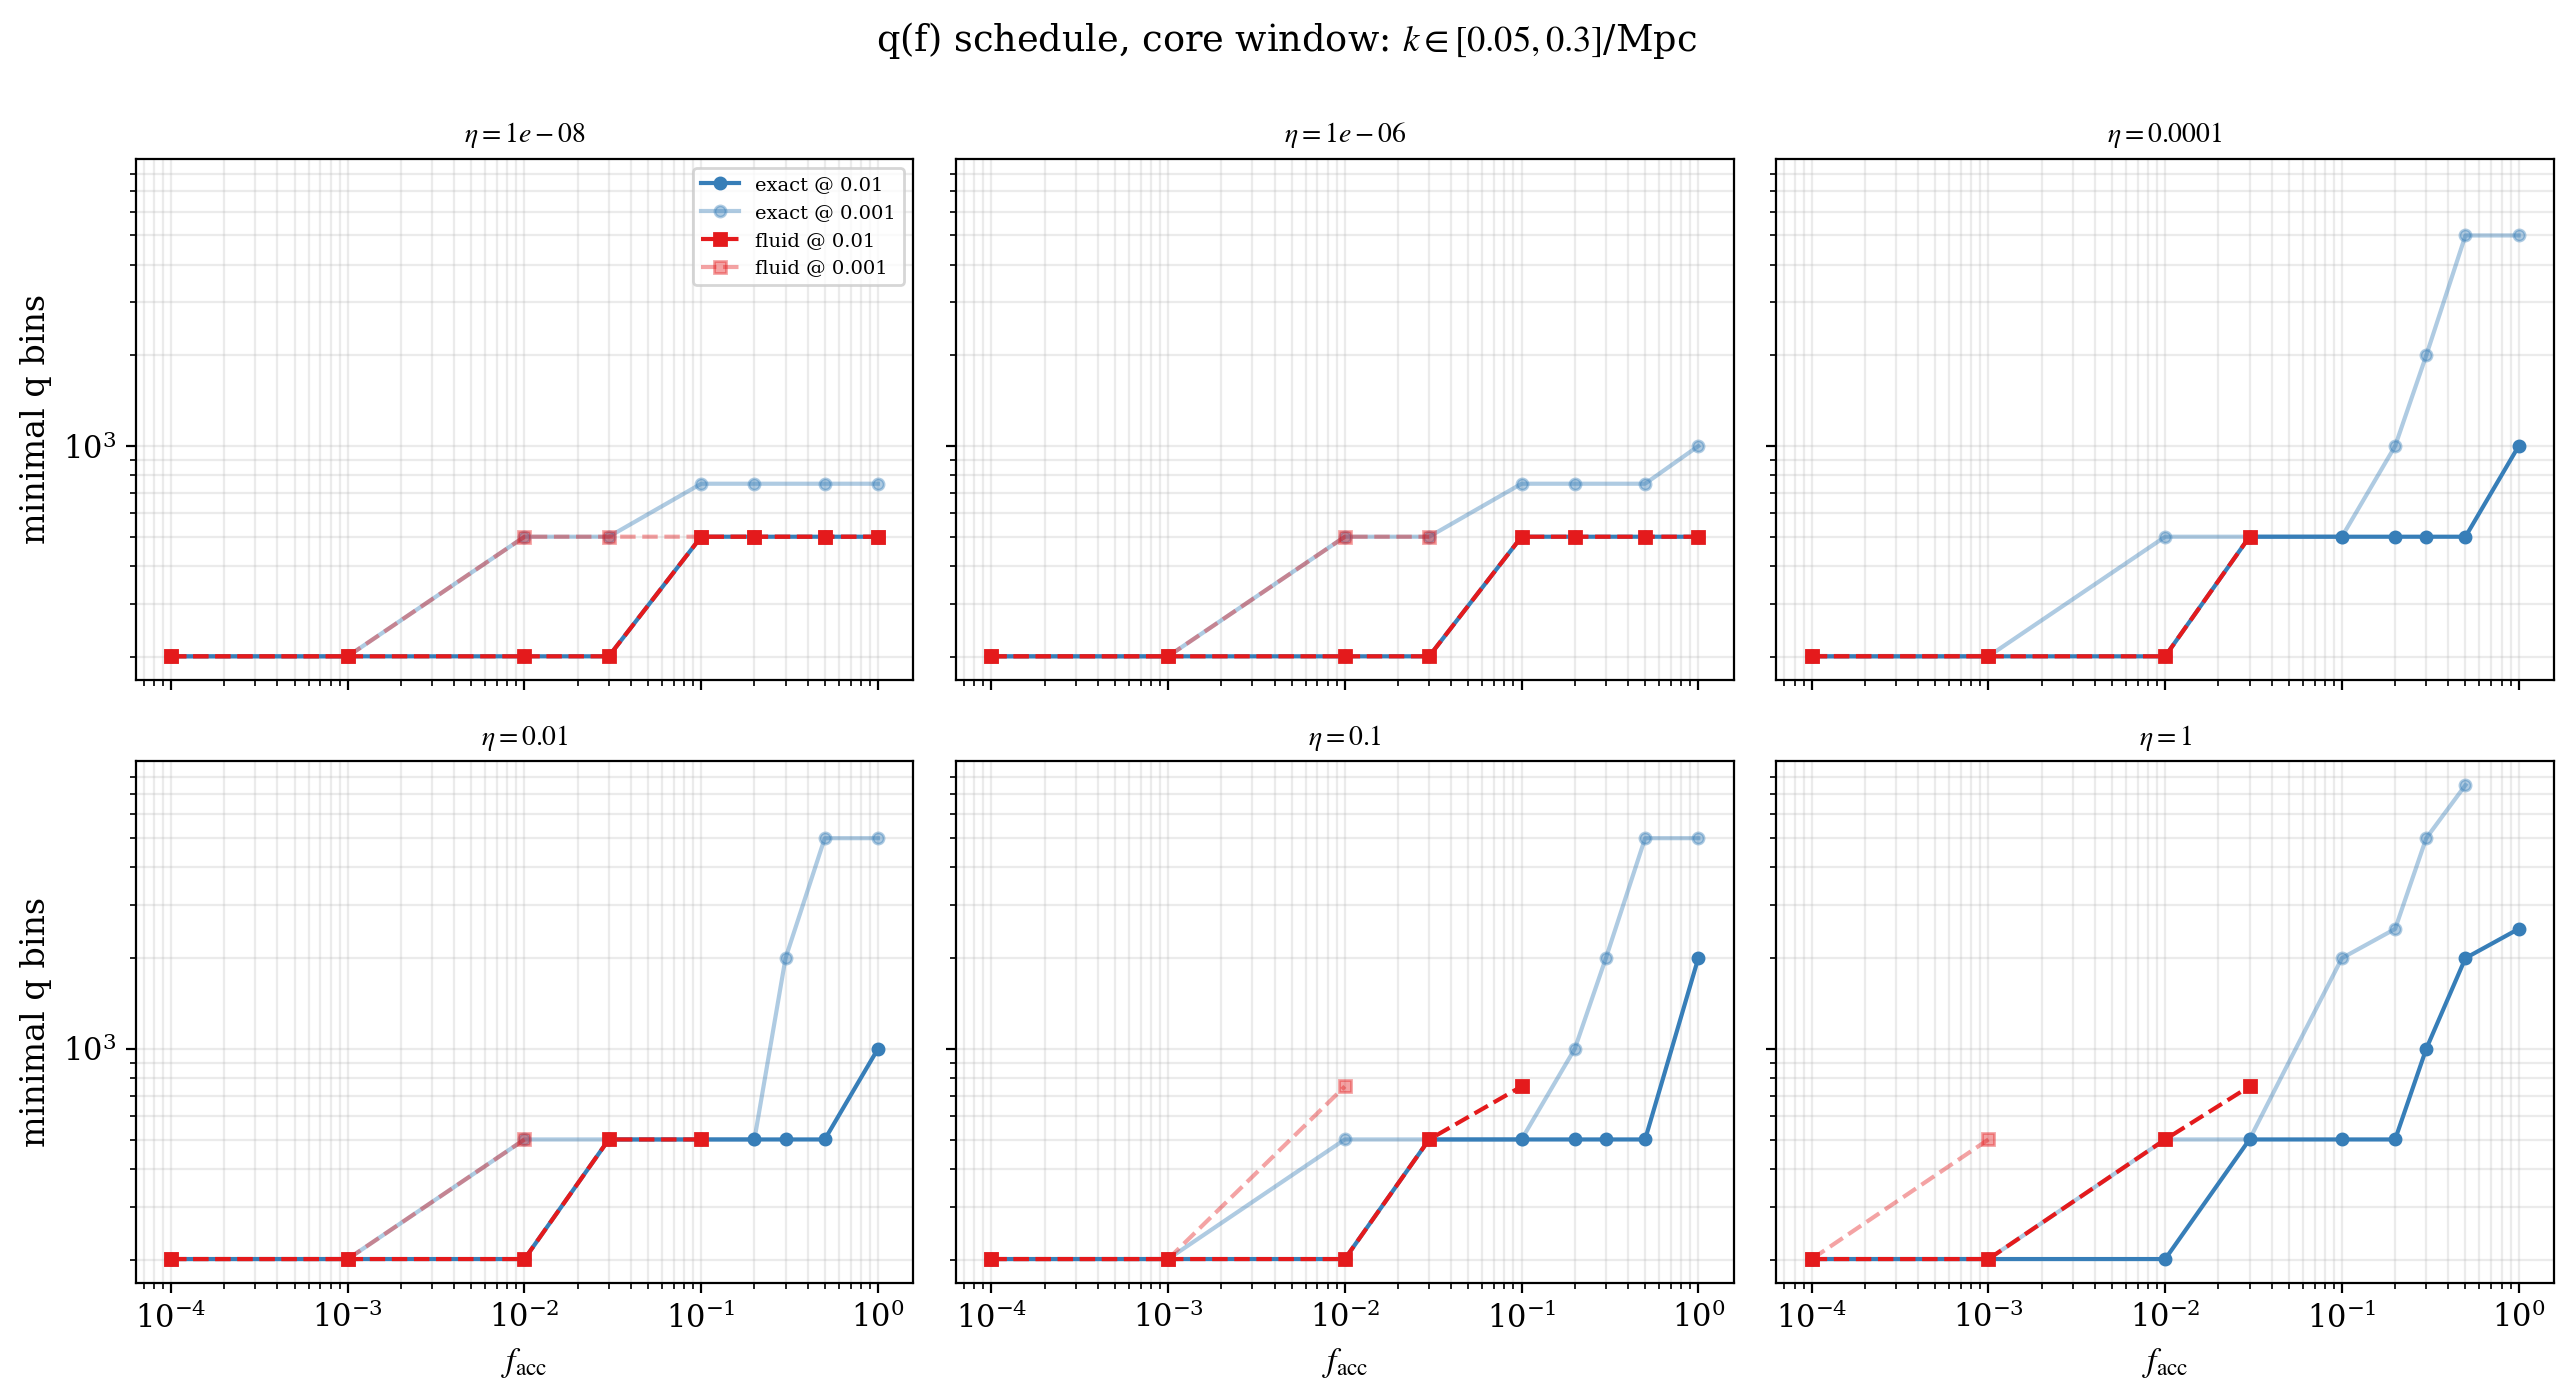

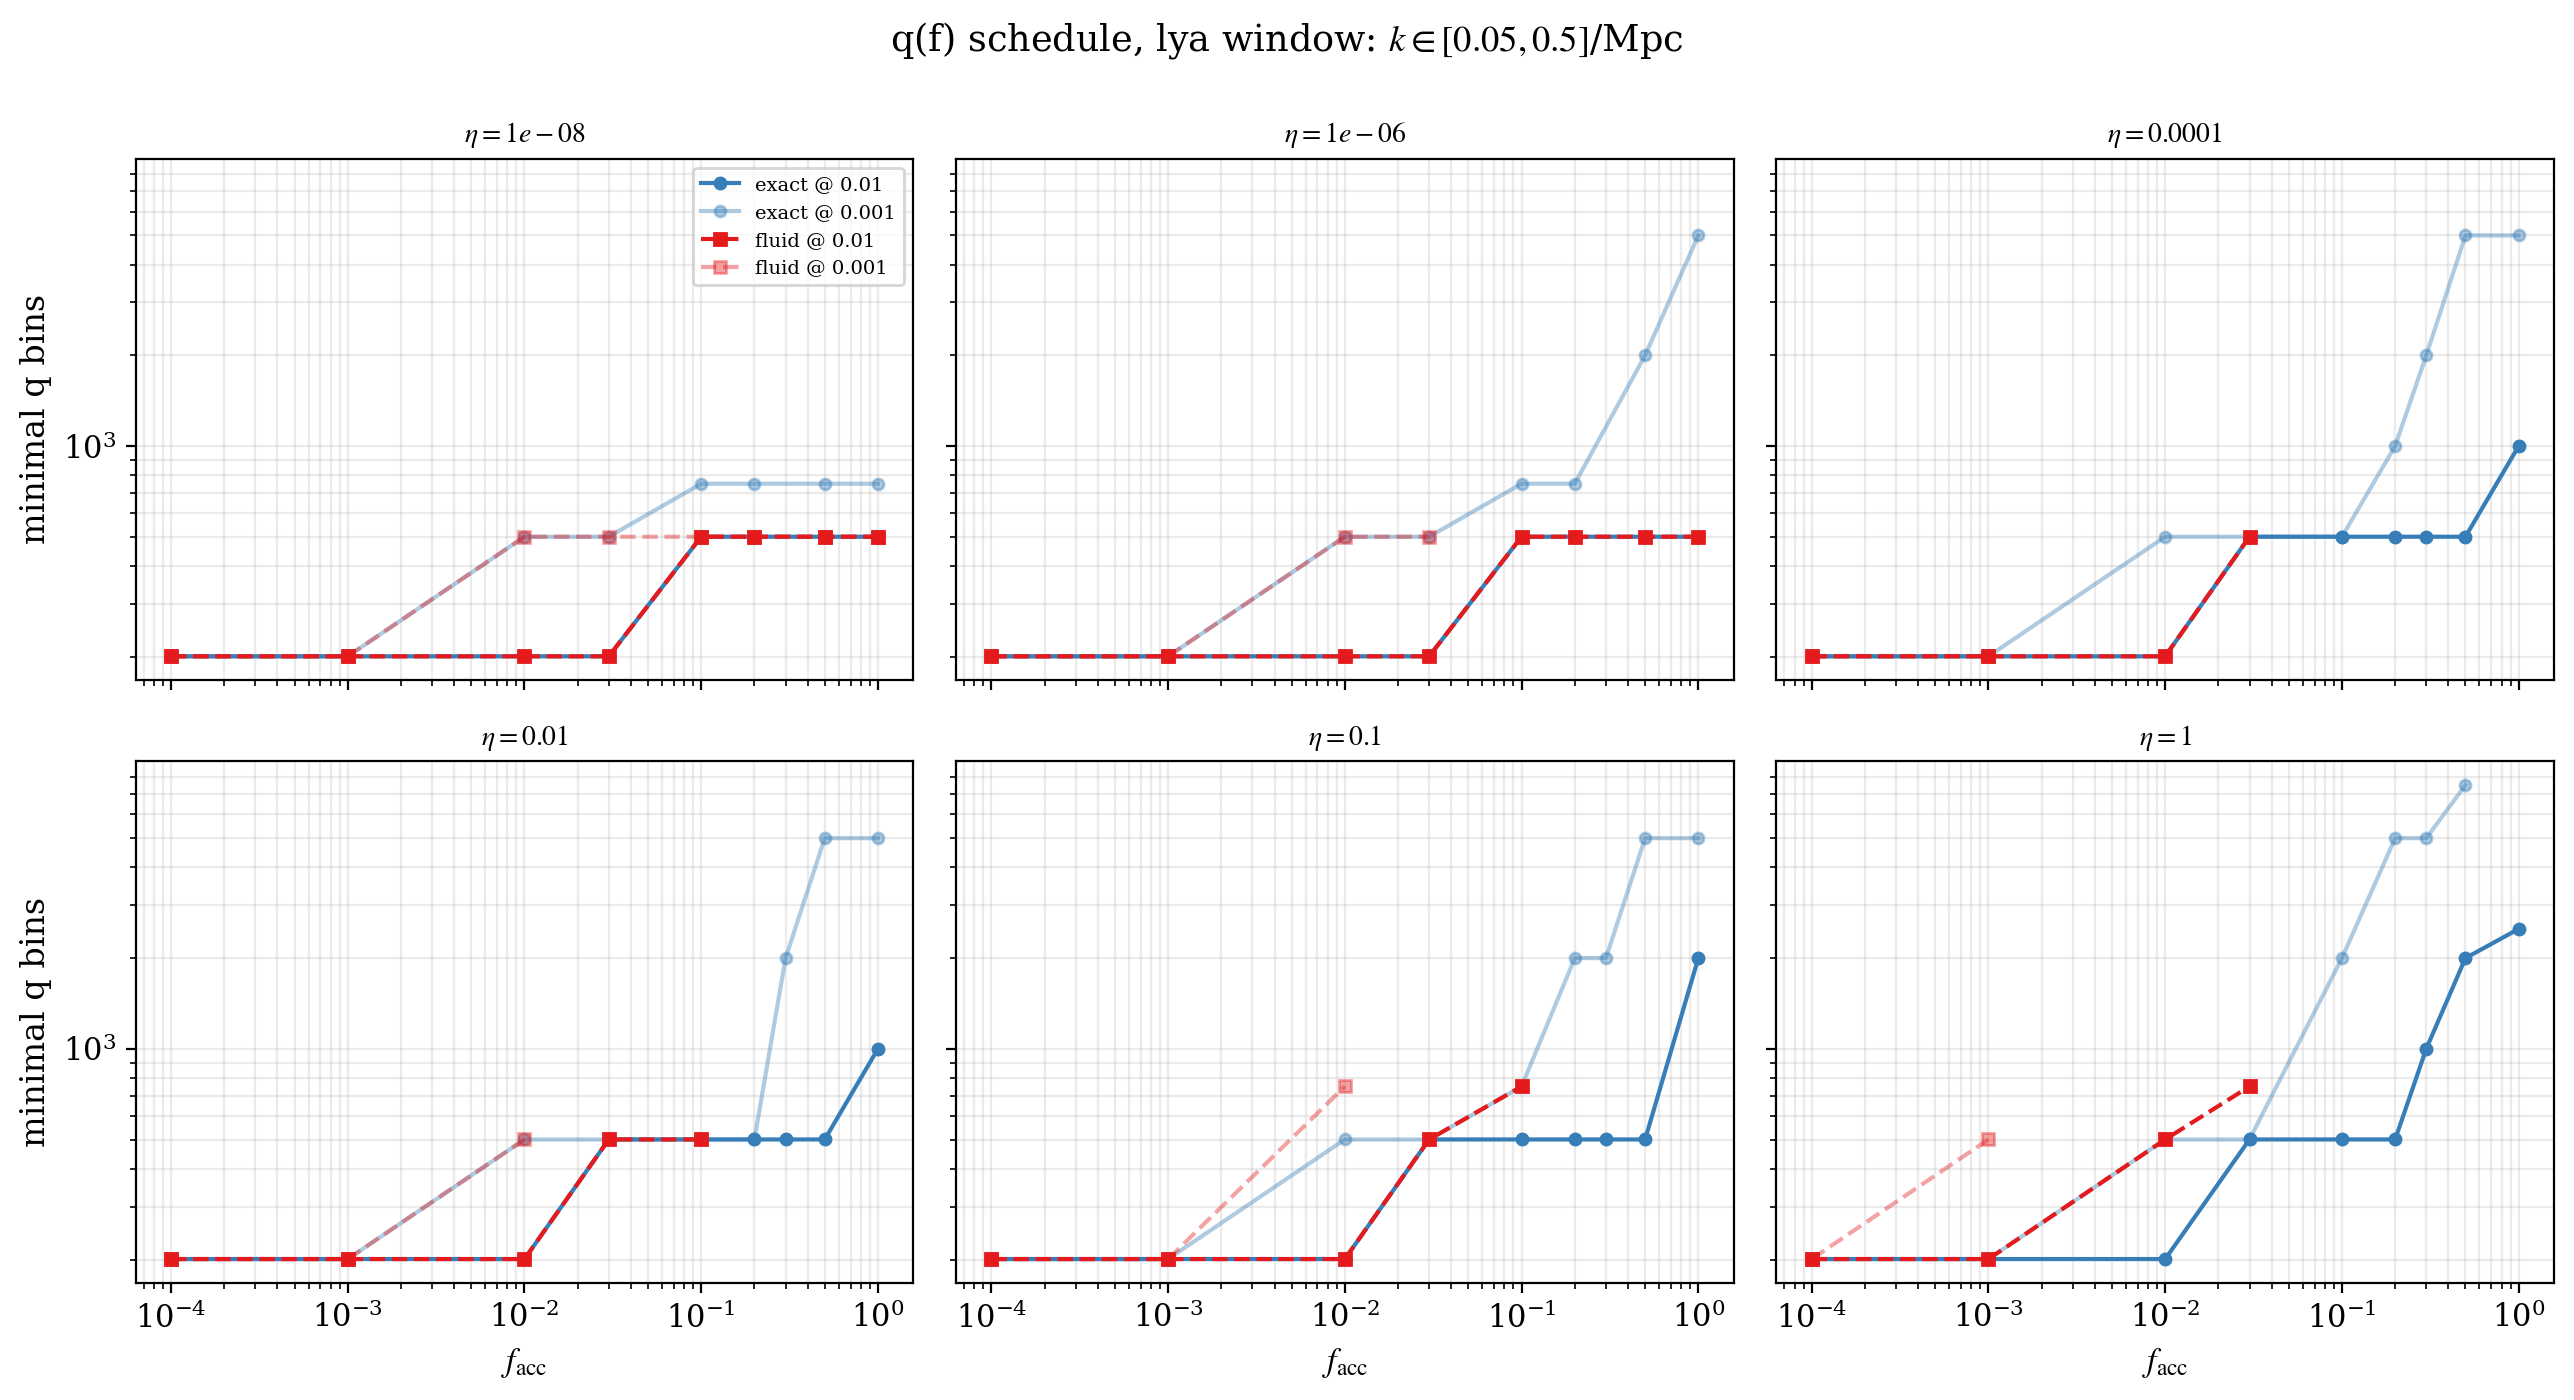

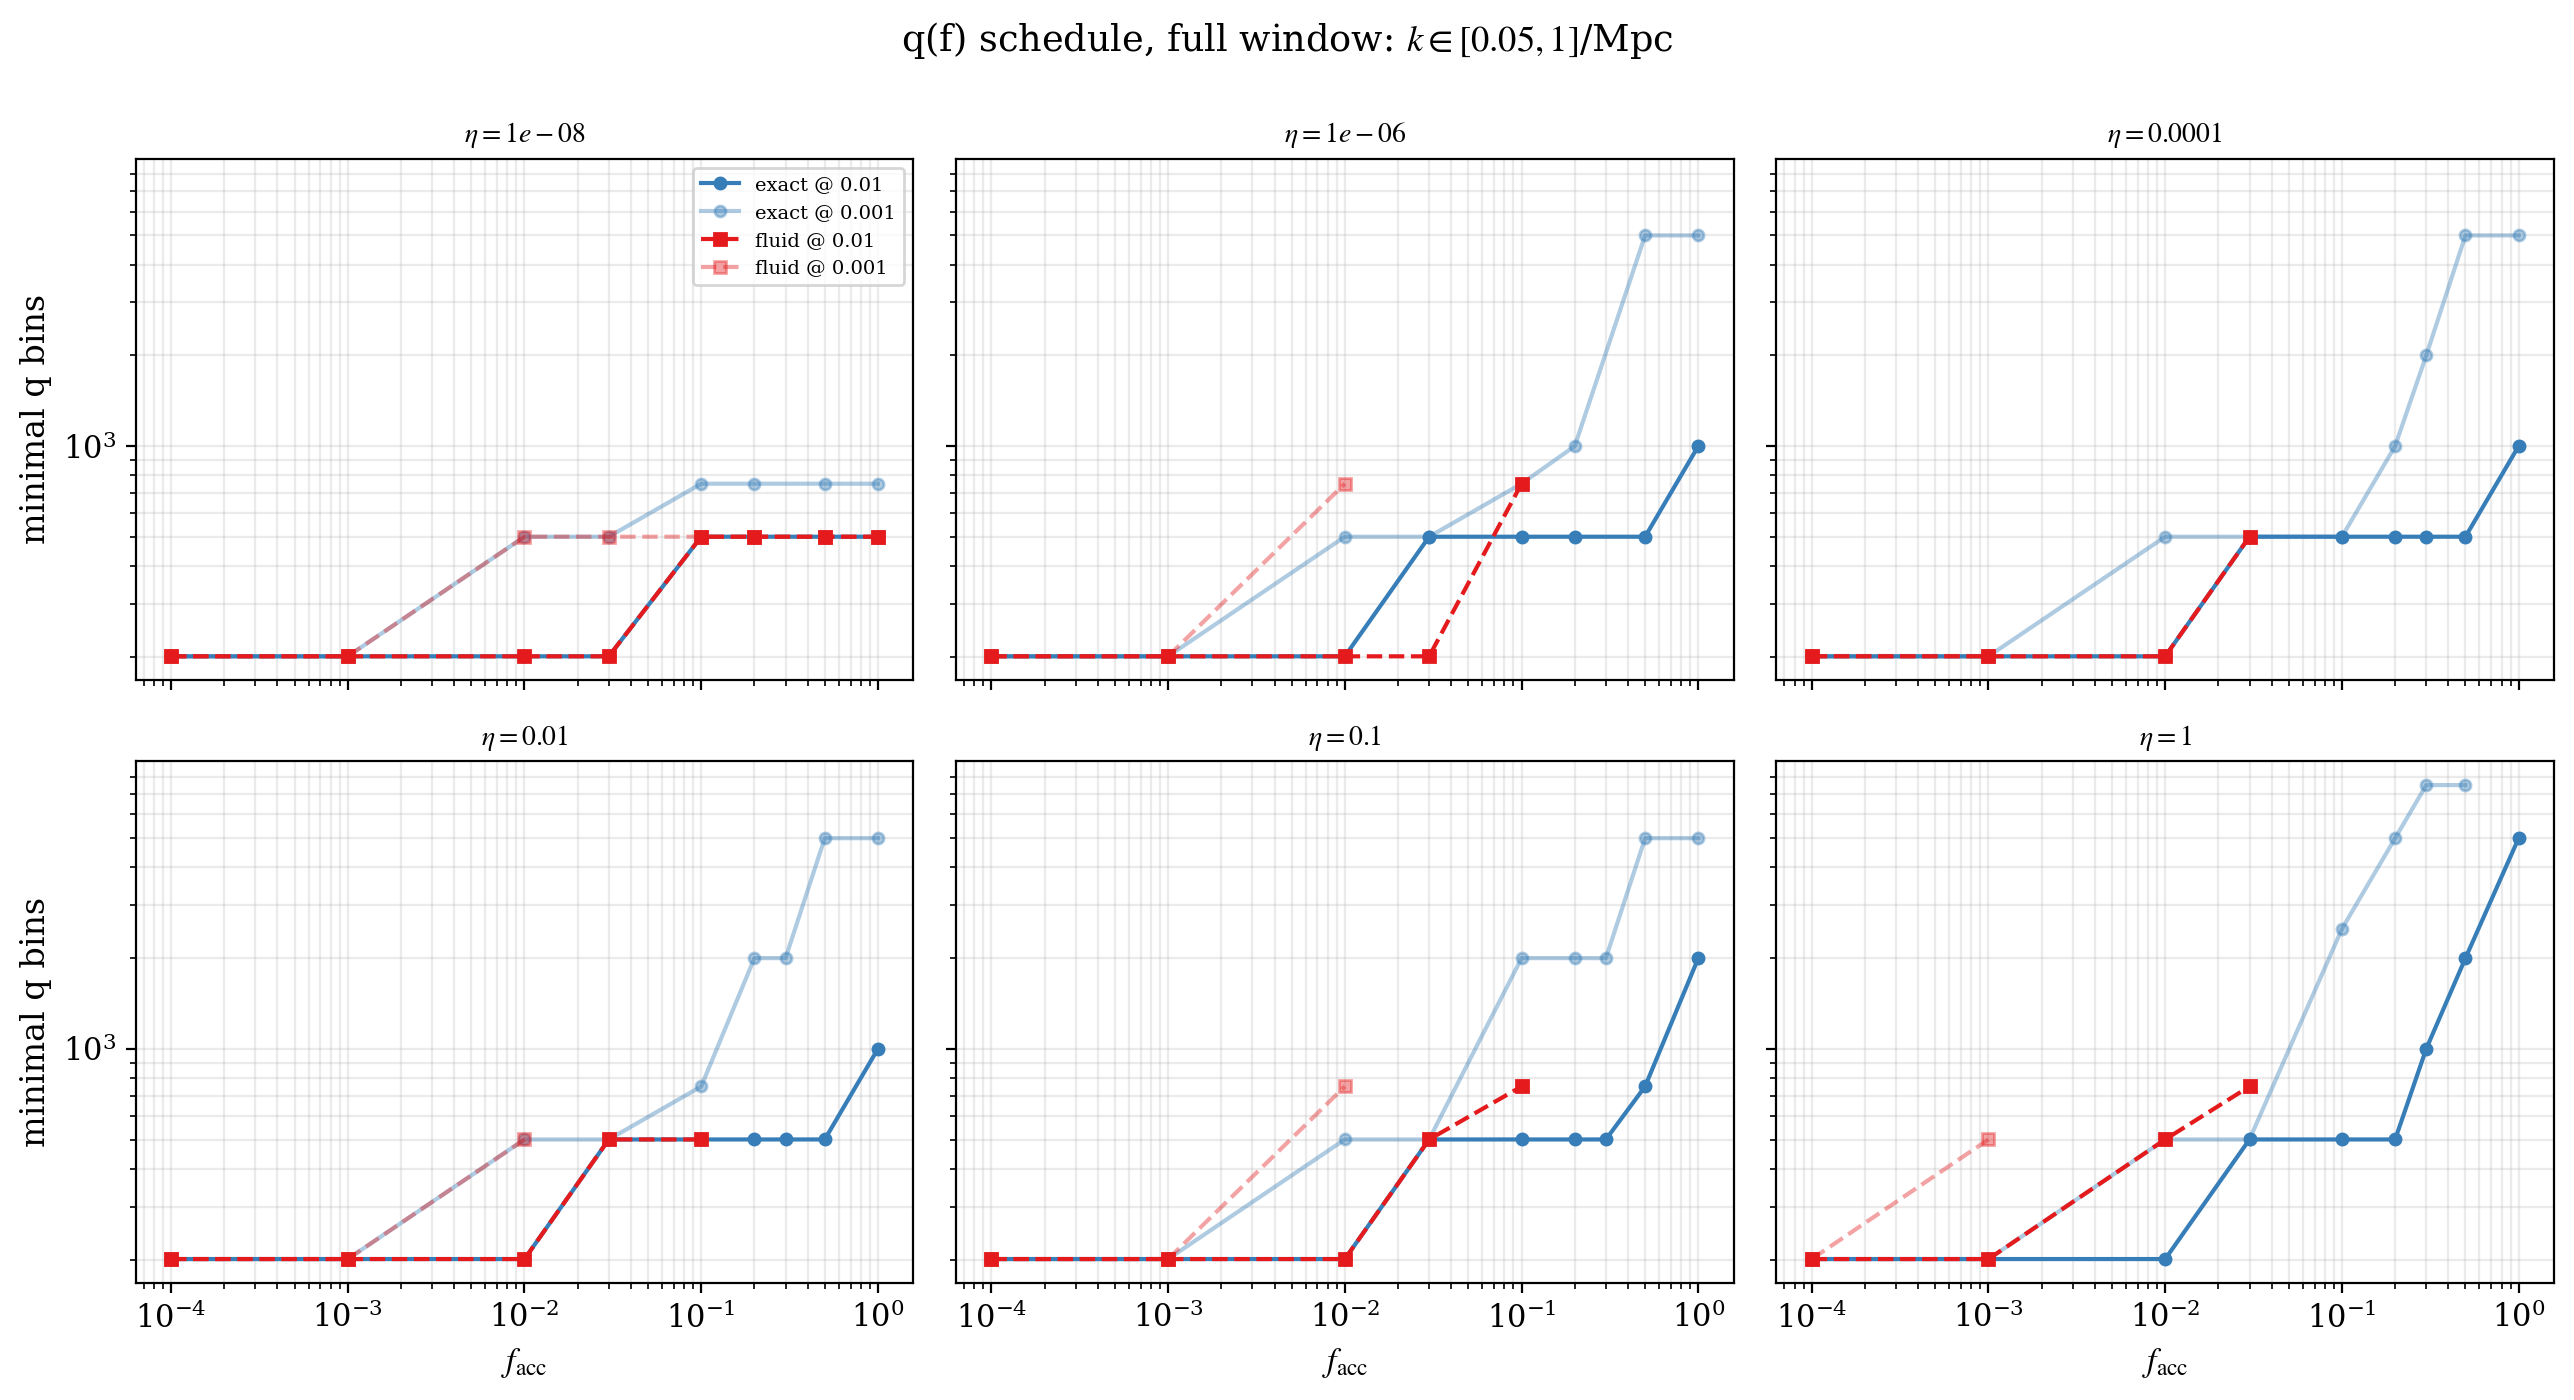

In [20]:
def minimal_q(kind, f_acc, eta, target, err_key='err_win'):
    q_values, err_values = ladder_curve(kind, f_acc, eta, err_key)
    ok = q_values[err_values <= target]
    return int(ok[0]) if len(ok) else None

def schedule_figure(window):
    err_key = 'err_' + window
    k_low, k_high = K_WINDOWS[window]
    fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
    for ax, eta in zip(axes.flat, ETA_GRID):
        for kind, linestyle, marker in (('exact', '-', 'o'), ('fluid', '--', 's')):
            for target, alpha in ((1e-2, 1.0), (1e-3, 0.4)):
                f_plot = [f_acc for f_acc in F_GRID
                          if minimal_q(kind, f_acc, eta, target, err_key)]
                q_plot = [minimal_q(kind, f_acc, eta, target, err_key) for f_acc in f_plot]
                if f_plot:
                    ax.loglog(f_plot, q_plot, linestyle, marker=marker, ms=4, alpha=alpha,
                              color='#377eb8' if kind == 'exact' else '#e41a1c',
                              label='{} @ {:g}'.format(kind, target) if eta == ETA_GRID[0] else None)
        ax.set_title(r'$\eta = {:g}$'.format(eta), fontsize=10)
        ax.grid(alpha=0.25, which='both')
    for ax in axes[-1]:
        ax.set_xlabel(r'$f_{\rm acc}$')
    for ax in axes[:, 0]:
        ax.set_ylabel(r'minimal q bins')
    axes[0, 0].legend(fontsize=7)
    fig.suptitle('q(f) schedule, {} window: $k \\in [{:g}, {:g}]$/Mpc'.format(
        window, k_low, k_high), y=0.995)
    fig.tight_layout()
    return fig

for window_name in K_WINDOWS:
    schedule_figure(window_name)

## 4. Accuracy–cost Pareto: is the fluid ever the better deal?

Each curve walks the q-ladder for one corner in the (wall time, error) plane. The fluid
wins wherever its dashed curve sits below-left of the exact solid curve — same accuracy
for less time, or better accuracy at the same time.

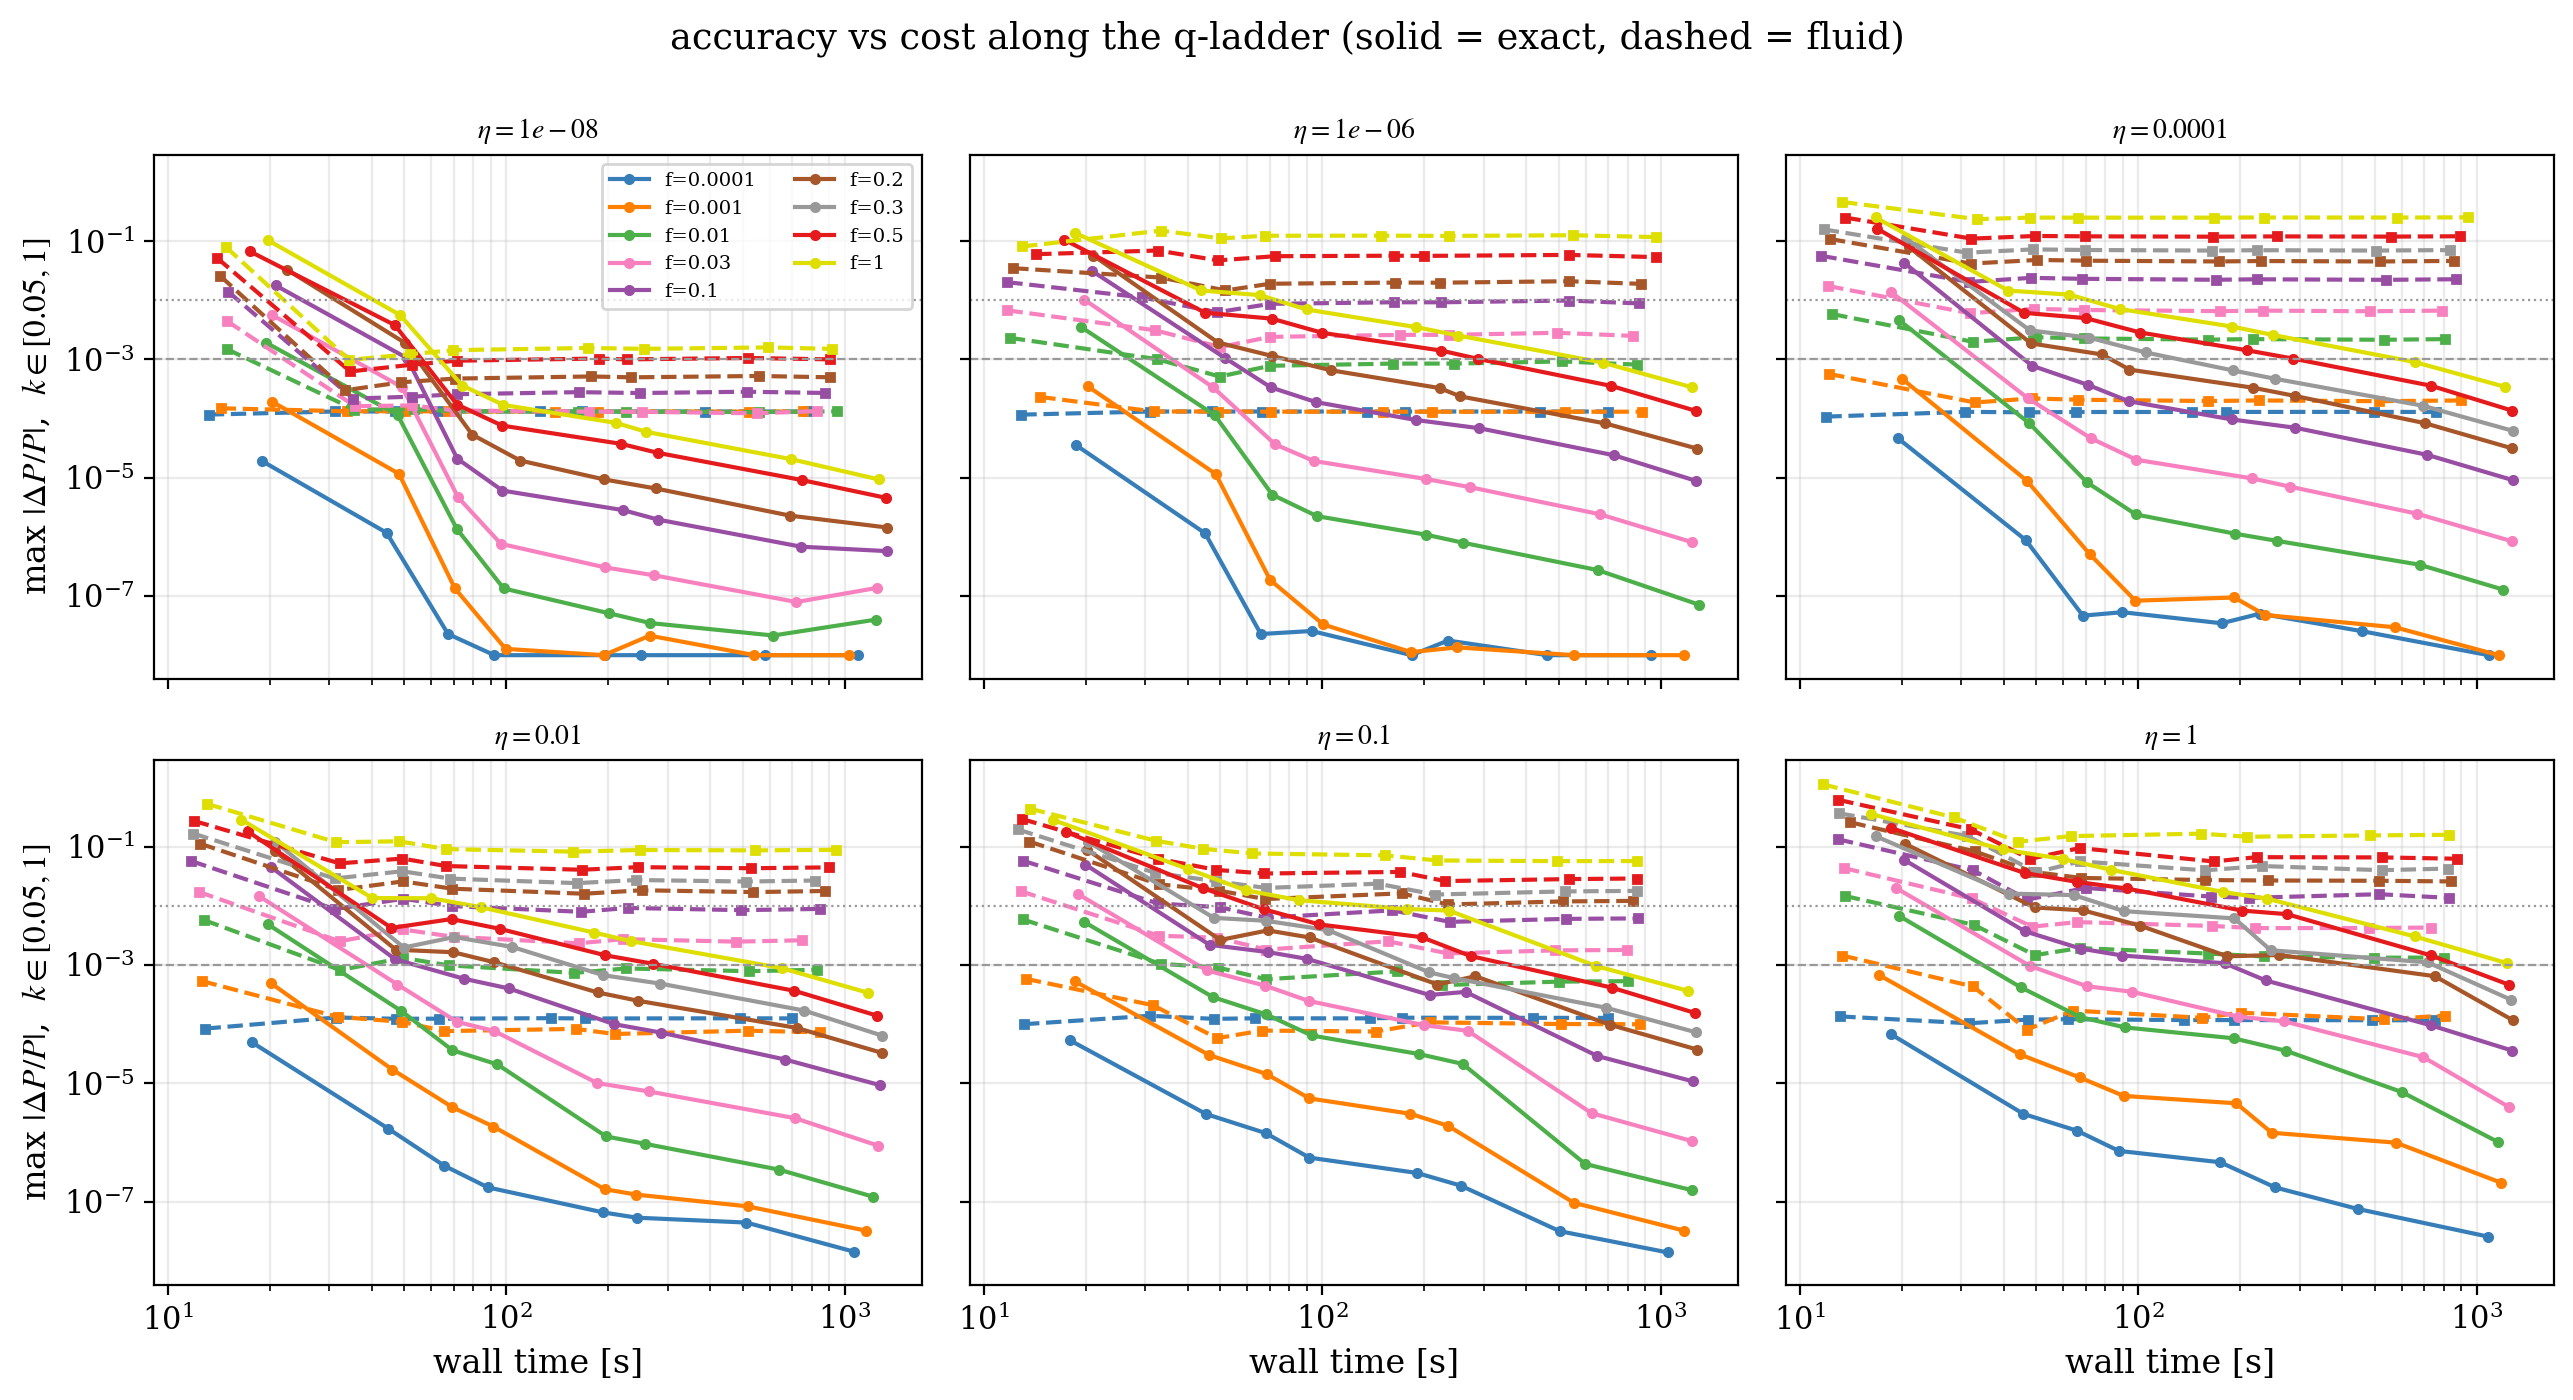

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ax, eta in zip(axes.flat, ETA_GRID):
    for f_acc in F_GRID:
        for kind, linestyle, marker in (('exact', '-', 'o'), ('fluid', '--', 's')):
            qs = [q for q in Q_LADDER if (kind, f_acc, eta, q) in metrics]
            if not qs:
                continue
            seconds = [metrics[(kind, f_acc, eta, q)]['seconds'] for q in qs]
            errors = [max(metrics[(kind, f_acc, eta, q)]['err_full'], 1e-8) for q in qs]
            ax.loglog(seconds, errors, linestyle, marker=marker, ms=3,
                      color=color_of_f[f_acc])
    for target, style in ((1e-2, ':'), (1e-3, '--')):
        ax.axhline(target, color='0.6', lw=0.8, ls=style)
    ax.set_title(r'$\eta = {:g}$'.format(eta), fontsize=10)
    ax.grid(alpha=0.25, which='both')
for ax in axes[-1]:
    ax.set_xlabel('wall time [s]')
for ax in axes[:, 0]:
    ax.set_ylabel(r'max $|\Delta P/P|$,  $k \in [0.05, 1]$')
axes[0, 0].legend(handles=f_legend_handles(), ncol=2, fontsize=7)
fig.suptitle('accuracy vs cost along the q-ladder (solid = exact, dashed = fluid)', y=0.995)
fig.tight_layout()

In [22]:
# --- sigma8 view: smallest rung with |d sigma8| < 1e-3, plus the fluid closure floor ---
header = 'f        eta      | exact q(ds8<1e-3)  fluid q(ds8<1e-3) | fluid floor err_win@q=7501'
print(header); print('-' * len(header))
for f_acc in F_GRID:
    for eta in ETA_GRID:
        def min_q_sig8(kind):
            qs = [q for q in Q_LADDER if (kind, f_acc, eta, q) in metrics
                  and metrics[(kind, f_acc, eta, q)]['dsig8'] < 1e-3]
            return qs[0] if qs else None
        floor = metric('fluid', f_acc, eta, Q_LADDER[-1], 'err_win')
        if min_q_sig8('exact') is None and min_q_sig8('fluid') is None and np.isnan(floor):
            continue
        print('{:<8g} {:<8g} | {!s:>17} {!s:>18} | {:>26}'.format(
            f_acc, eta, min_q_sig8('exact'), min_q_sig8('fluid'),
            '' if np.isnan(floor) else '{:.2e}'.format(floor)))

f        eta      | exact q(ds8<1e-3)  fluid q(ds8<1e-3) | fluid floor err_win@q=7501
-------------------------------------------------------------------------------------
0.0001   1e-08    |               201                201 |                   1.31e-04
0.0001   1e-06    |               201                201 |                   1.31e-04
0.0001   0.0001   |               201                201 |                   1.28e-04
0.0001   0.01     |               201                201 |                   1.25e-04
0.0001   0.1      |               201                201 |                   1.27e-04
0.0001   1        |               201                201 |                   1.16e-04
0.001    1e-08    |               201                201 |                   1.31e-04
0.001    1e-06    |               201                201 |                   1.30e-04
0.001    0.0001   |               201                201 |                   2.01e-04
0.001    0.01     |               201                2

## Takeaways

*(fill in after the cluster cache lands)*

- **q(f) schedule** — how does the minimal q scale with f, and does eta move it?
  (Prior boundary result: exact@1001 suffices only for f ≲ 0.1 against 5001.)
- **Fluid floor** — where the fluid's high-q plateau sits per (f, eta): that is the closure
  error with adiabatic ceff2 + dynamical shear, independent of momentum resolution.
- **Pareto verdict** — corners where the fluid dominates the exact arm at equal wall time,
  and corners where it never reaches the 1% target at all.